# TP3 : Analyse en composantes principales (PCA)

Importez les bibliothèques suivantes.

In [4]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Le TP précédent portait sur le K-clustering. Le présent TP utilisant les résultats de ce dernier, voici une cellule définissant la classe `MyKMeans` ainsi que la fonction `accuracy(labels)`.

In [5]:
def assign_clusters(data,centroids):
    distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def random_centroids(data,k):
    indices = np.random.choice(data.shape[0],k,replace=False)
    centroids = data[indices]
    return centroids

def update_centroids(data,k, labels):
    new_centroids = np.zeros((k, data.shape[1]))
    for i in range(k):
        points_in_cluster = data[labels == i]
            
        if len(points_in_cluster) > 0:
            new_centroids[i] = points_in_cluster.mean(axis=0)
        else:
            new_centroids[i] = data[np.random.choice(len(data))]
                
    return new_centroids

class MyKMeans:
    def __init__(self, n_clusters, max_iter=100, tol=1e-4):
        self.k = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        
        self.centroids = None
        self.labels = None

    def fit(self, data):
        # 1. Init
        self.centroids = random_centroids(data,self.k)
        
        for i in range(self.max_iter):
            old_centroids = self.centroids.copy()
            self.labels = assign_clusters(data, self.centroids)
            self.centroids = update_centroids(data, self.k, self.labels)
            
            diff = np.linalg.norm(self.centroids - old_centroids)
            if diff < self.tol:
                print(f"Convergence atteinte à l'itération {i}")
                break
        else:
            print(f"Arrêt : Max itérations ({self.max_iter}) atteintes.")
            
        return self

def accuracy(labels):
    ct = pd.crosstab(labels, y)
    row_maxes = ct.max(axis=1)
    sum_of_maxes = row_maxes.sum()
    total_elements = ct.values.sum()
    proportion = sum_of_maxes / total_elements
    return proportion

Nous avons également besoin de la fonction affichant une image ou une liste d'images (au format 784 pixels).

In [6]:
def display_image(source):
    images = []

    # Case 1: A single flat image (1D array of 784)
    if isinstance(source, np.ndarray) and source.size == 784:
        images = [source]
    
    # Case 2: A list or array of images
    elif isinstance(source, (list, np.ndarray)):
        # If the first element is a flat vector of 784
        if hasattr(source[0], 'shape') and (source[0].size == 784 or source[0].shape == (28, 28)):
            images = source
        else:
            print("Error: Elements in the list do not have the correct dimensions.")
            return
    else:
        print("Error: Unsupported input type.")
        return
    
    l = len(images)
    c = math.ceil(l / 3)
    fig, axes = plt.subplots(c, 3, figsize=(12, 5))

    for i, ax in enumerate(axes.flat):
        if i < l:
            img = images[i].reshape(28, 28)
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Image {i + 1}")
        ax.axis('off')

Enfin, importez les jeux de données.

In [7]:
## from google.colab import files
## data_to_load1 = files.upload()
## import io
## df_pixels = pd.read_csv(io.BytesIO(data_to_load1['pixels.csv']))

df_pixels = pd.read_csv("pixels.csv")
X = df_pixels.to_numpy(dtype="uint8")
df_label = pd.read_csv("labels.csv")
y = df_label["label"].values

L'objectif de ce TP va consister en la définition progressive (par Monkey-Patching) d'une classe `MyPCA` implémentant l'alogirthme d'analyse en composantes principales. 

In [8]:
class MyPCA:
    def __init__(self, n_components, standardize=False):
        
        self.n_components = n_components
        self.standardize = standardize
        
        self.mean = None
        self.std = None
        self.components = None
        self.explained_variance = None
        self.total_variance = None
        self.prepared_matrix = None

print("Classe initialisée.")

Classe initialisée.


## Exercice 1 

1. La première étape est celle de préparation des données. Il existe deux versions de la PCA : la PCA sur la matrice de covariance (la matrice de données est centrée) et la PCA sur la matrice de corrélation (la matrice de données est centrée et réduite). Construisez une fonction `prepare_data(data,standardize=False)`qui renvoie une liste `prepared_data, mean, std' où:

- `prepared_data` est la matrice de données préparée pour la PCA (le booléen `standardize` determine quelle version est utilisée),
- `mean` est la donnée moyenne,
- `std` est l'écart-type (il faut la modifier légèrement ($0.00000001$ par exemple) pour assurer qu'elle n'est jamais 0). 

In [9]:
## Écrivez votre code ici.
def prepare_data(prepared_data,standardize=False):
    mean=np.mean(prepared_data,axis=0)
    prepared_data=prepared_data-mean
    
    
    if standardize:
        std=np.std(prepared_data,axis=0)
        std = np.where(std == 0, 0.00000001, std)
        prepared_data=prepared_data/std
    else : 
          std = np.ones(prepared_data.shape[1])

    return prepared_data,mean,std


2. Une fois la matrice de données préparée, on l'utilise pour calculer la comatrice (matrice de covariance ou matrice de corrélation). Construisez une fonction `compute_comatrix(data_prepared)` renvoyant cette comatrice.

In [10]:
## Écrivez votre code ici.
def compute_matrix(data_prepared):
    m=data_prepared.shape[0]-1
    
    return (1/m)*(data_prepared.T @ data_prepared)

## Exercice 2 

Une fois la comatrice calculée, on opère une décomposition spectrale pour récupérer ses valeurs propres et ses vecteurs propres. On peut ensuite choisir les $n$ composantes les plus importantes. Construisez une fonction `get_principal_components(comatrix, n_components)` qui renvoie une liste `top_eigenvalues, top_eigenvectors, total` où :

- `top_eigenvalues` est le vecteur de $n$ plus granges valeurs propres ordonnées de la plus petites à la plus grandes,
- `top_eigenvectors` est la matrice où chacune des $n$ lignes correspond à un vecteur propre et où ils sont ordonnés dans l'ordre correspondant à leurs valeurs propres respectives,
- `total` est la somme de toutes les valeurs propres.

Attention à l'ordre et aux dimensions de vos objets ! Utilisez la fonction `np.linalg.eigh` (**[documentation](https://numpy.org/doc/2.1/reference/generated/numpy.linalg.eigh.html#numpy.linalg.eigh)**).

In [11]:
def get_principal_components(comatrix, n_components):
    eigenvalues, eigenvectors = np.linalg.eig(comatrix)

    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors)
    i = np.argsort(eigenvalues)[::-1]

    eigenvalues = eigenvalues[i]
    eigenvectors = eigenvectors[:, i]

    top_eigenvalues = eigenvalues[:n_components]
    top_eigenvectors = eigenvectors[:, :n_components]

    total = np.sum(eigenvalues)

    return top_eigenvectors, top_eigenvalues, total




## Exercice 3 

Nous allons maintenant achever la définition de la classe `MyPCA`.

1. Construisez et attribuer à `MyPCA` une fonction `fit(self,data)` appliquant une PCA à la matrice `data`. Il va s'agir d'assigner les 6 attributs de la classe `MyPCA` qui ne l'ont pas été à l'initialisation.

In [12]:
## Écrivez votre code ici.
def fit(self,data):
    centered_data,mean,std=prepare_data(data,self.standardize)
    comatrix=compute_matrix(centered_data)
    self.components,self.explained_variance,self.total_variance=get_principal_components(comatrix,self.n_components)
    self.mean,self.std=mean,std
    self.prepared_matrix=centered_data
MyPCA.fit = fit

2. Construisez et attribuez à `MyPCA` une fonction `transform(self,data)` renvoyant la projection de la matrice `data` dans l'espace des composantes principales de l'instance de la classe.

In [13]:
## Écrivez votre code ici.
def transform(self,data):
    centered_data=data-self.mean
    if self.standardize:
        centered_data=centered_data/self.std
    return np.dot(centered_data,self.components)
MyPCA.transform = transform   

    

3. Construisez et attribuez à `MyPCA` une fonction `inverse_transform(self,data_projected)` renvoyant la reconstruction dans l'espace original d'une matrice de données vivant dans l'espace des composantes principales de l'instance de la classe. 

In [14]:
## Écrivez votre code ici.
def inverse_transform(self,transformed_data):
    reconstructed_normalized=np.dot(transformed_data,self.components.T)
    if self.standardize:
        return reconstructed_normalized*self.std + self.mean
    else :
        return reconstructed_normalized + self.mean
MyPCA.inverse_transform = inverse_transform
    

## Exercice 4 

1. Créez une instance de la classe `MyPCA` afin de faire une PCA sur nos données (`X`) avec 6 composantes principles. Affichez les images correspondants aux 6 composantes principales.

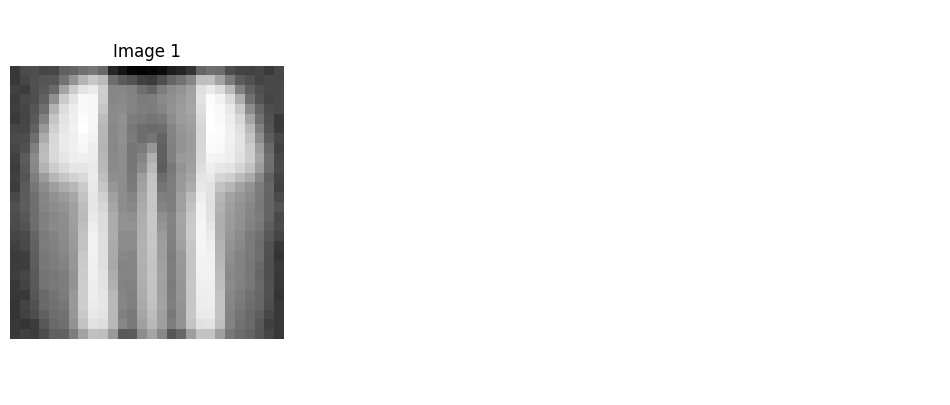

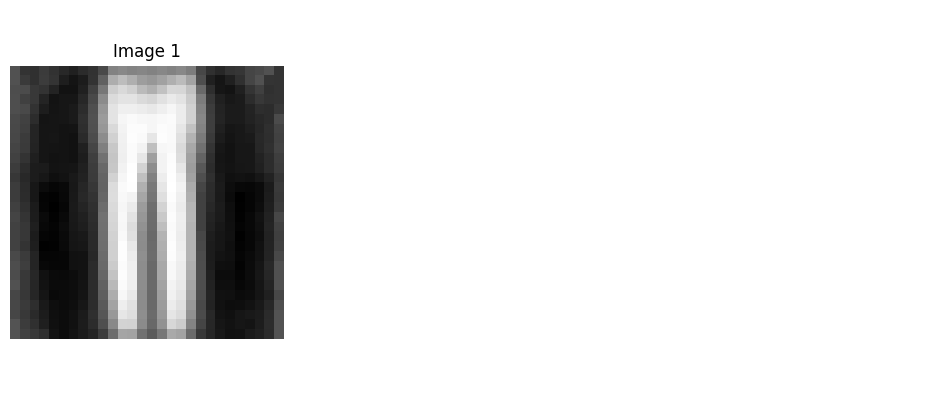

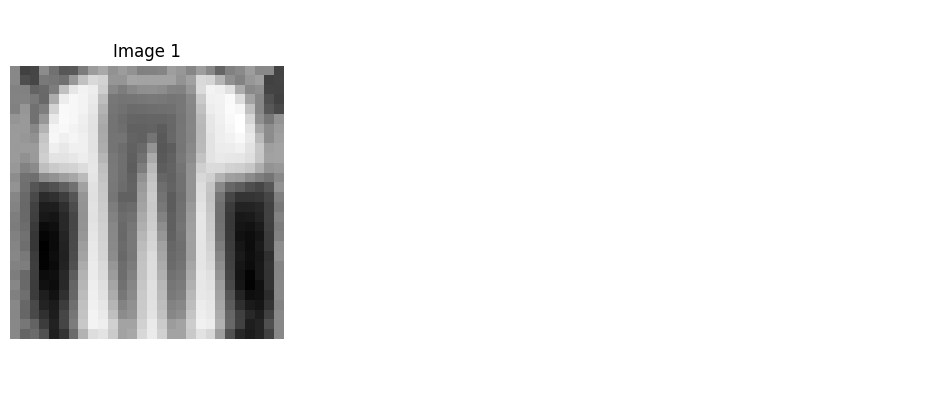

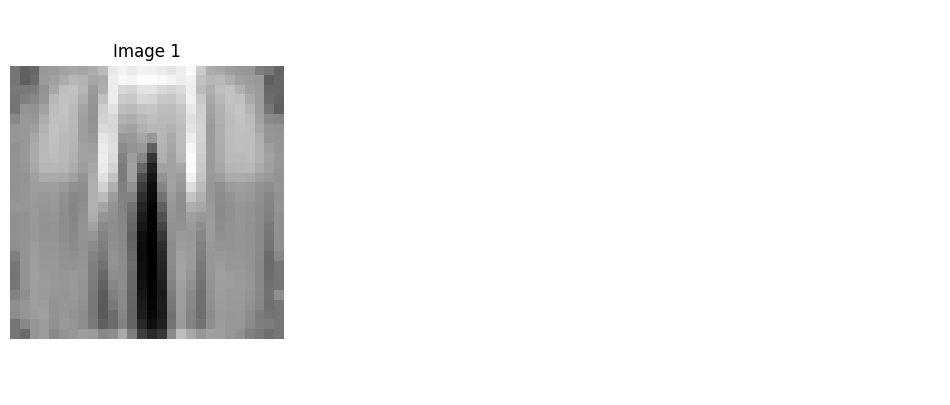

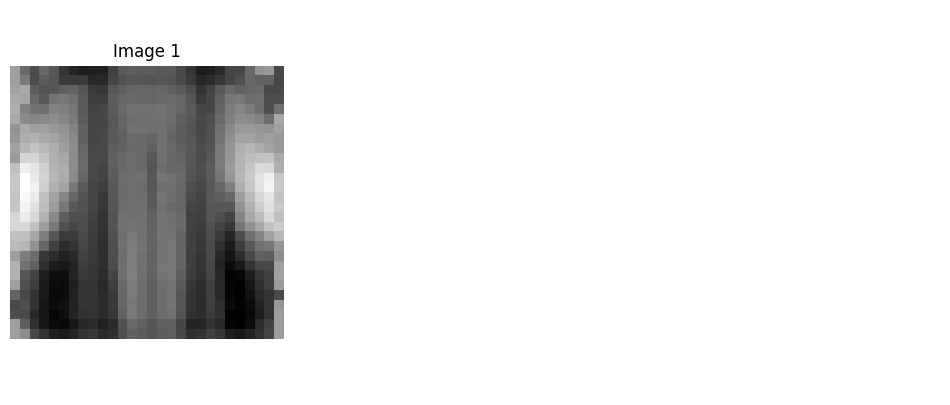

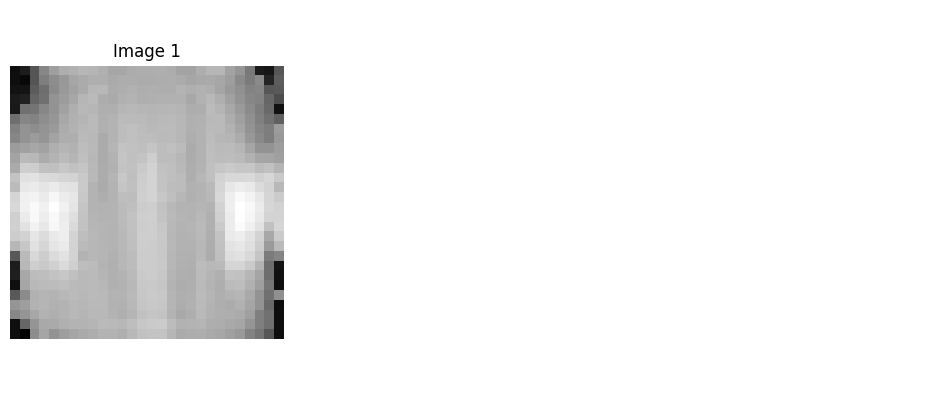

In [15]:
## Écrivez votre code ici.

mypca=MyPCA(6,True)
mypca.fit(X)
for i in range(0,6):
    display_image(np.real(mypca.components[:,i]))


2. Dessiner un graphique représentant, pour $i$ allant de 1 à 100, la part de la variance expliquée par les $i$ premières composantes principales. Utilisez `plt.plot` (**[documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)**).

Text(0.5, 1.0, 'Explained Variance by First i Components')

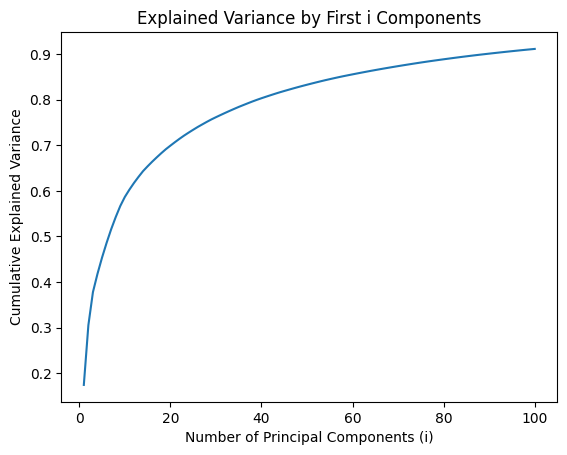

In [16]:
mypca=MyPCA(100,True)
mypca.fit(X)
ratio=mypca.explained_variance/mypca.total_variance
variance_cum= np.cumsum(ratio)
plt.plot(range(1, 101), variance_cum)
plt.xlabel("Number of Principal Components (i)")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by First i Components")

3. Choisissez une image dans nos données. Affichez là avec ses compressions (projection puis reconstruction) dans les $i$ premières composantes principales, pour $i$ prenant les valeurs 1,3,5,10,25,50,75 et 100.

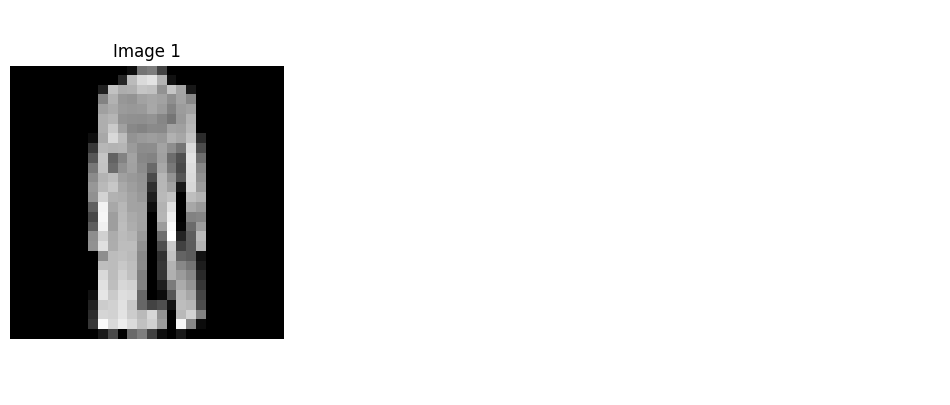

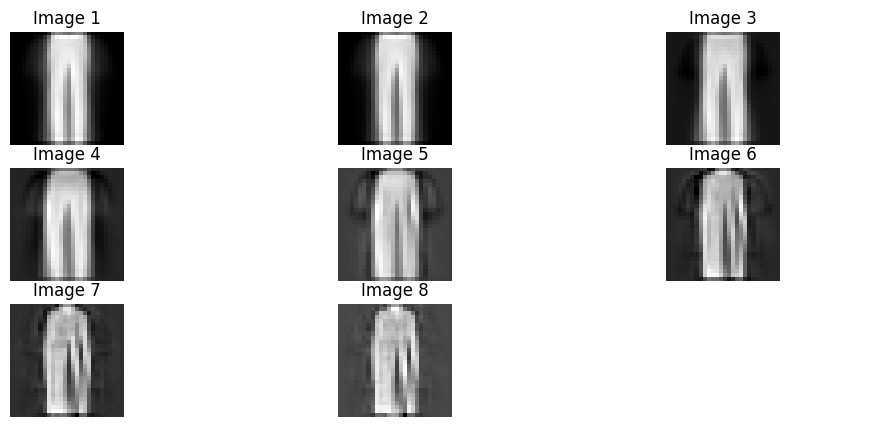

In [17]:


index = np.random.randint(0, X.shape[0])
image = X[index]
display_image(image)


liste = [1, 3, 5, 10, 25, 50, 75, 100]
max=max(liste)
mypca=MyPCA(max, False)
mypca.fit(X)
transformed_image_full = mypca.transform(image.reshape(1, -1))
reconstructed_list = []
for n_comp in liste:
   truncated_transformed = transformed_image_full.copy()
   truncated_transformed[:, n_comp:] = 0 
   reconstructed_image = mypca.inverse_transform(truncated_transformed)
   img = reconstructed_image.reshape(28, 28)
   reconstructed_list.append(img)
    
display_image(reconstructed_list)

  


## Exercice 5 

1. Utilisez la classe `MyPCA` pour projeter `X` sur deux dimensions. Visualisez le résultat dans un nuage de points avec `plt.scatter` (**[documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html#matplotlib.pyplot.scatter)**).

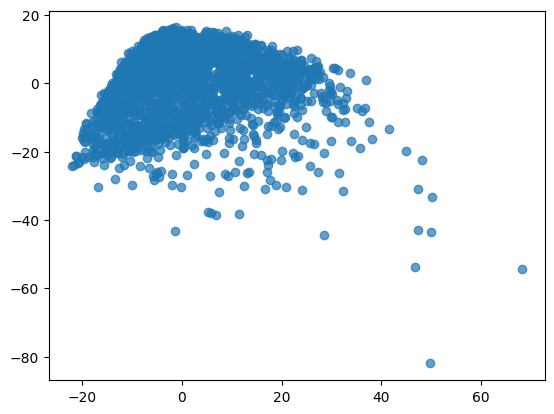

In [18]:
## Écrivez votre code ici.
pca_2=MyPCA(2,True)
pca_2.fit(X)
X_pca_2 = pca_2.transform(X)
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], alpha=0.7)


2. Dans ce nuage de points, colorez chaque point en fonction de son véritable label (le vecteur de labels est `y`).

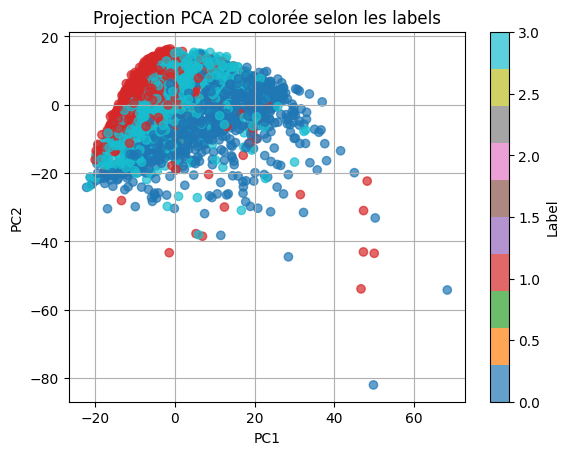

In [73]:
## Écrivez votre code ici.
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1],c=y, cmap='tab10', alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection PCA 2D colorée selon les labels")
plt.colorbar(label="Label")  
plt.grid(True)
plt.show()


3. Changez la couleur des points pour qu'ils soient colorés en fonction de leur classification par un K-clustering de `X` avec 3 clusters. Affichez les images correspondants aux centroïdes.

Convergence atteinte à l'itération 20


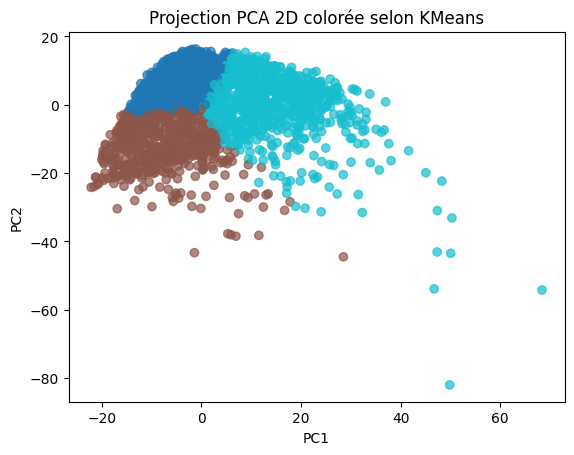

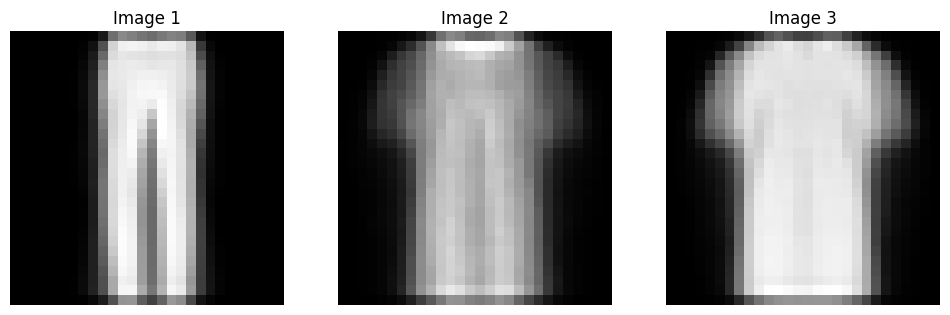

In [74]:
## Écrivez votre code ici.
mykm=MyKMeans(n_clusters=3)
mykm.fit(X)


labels= mykm.labels
plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=labels,          
    cmap='tab10',       
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection PCA 2D colorée selon KMeans")
display_image(mykm.centroids)

4. Enfin, changez la couleur des points pour qu'ils soient colorés en fonction de leur classification par un K-clustering de la projection PCA de `X` en 2 dimensions, avec 3 clusters. Affichez les images correspondants aux centroïdes.

Convergence atteinte à l'itération 10


Text(0.5, 1.0, 'Projection PCA 2D colorée selon KMeans sur X_pca_2')

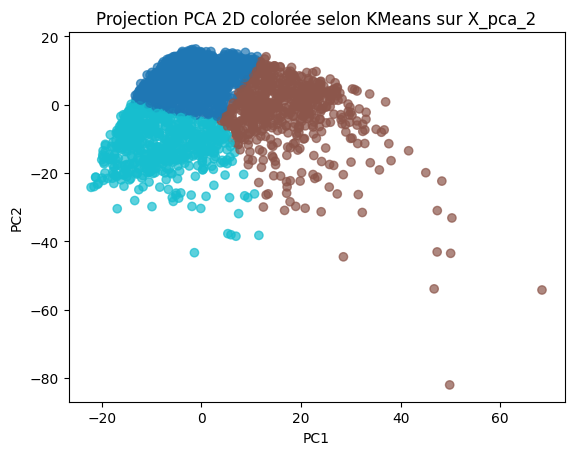

In [75]:
## Écrivez votre code ici.
km=MyKMeans(n_clusters=3)
km.fit(X_pca_2)
labels2= km.labels
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1],c=labels2, cmap='tab10', alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection PCA 2D colorée selon KMeans sur X_pca_2")

## Exercice 6 

1. Dessinez un graphe calculant la précision (`accuracy`) des labels obtenus par un K-clusterings de la projection PCA de `X` dans ses $i$ premières composantes principales avec 3 clusters, pour $i$ allant de 1 à 40. Utilisez `plt.plot`. 

Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 12
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 10
Convergence atteinte à l'itération 11
Convergence atteinte à l'itération 10
Convergence atteinte à l'itération 9
Convergence atteinte à l'itération 31
Convergence atteinte à l'itération 11
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 23
Convergence atteinte à l'itération 13
Convergence atteinte à l'itération 30
Convergence atteinte à l'itération 20
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 10
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 16
Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 10
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 10
Convergence atteinte à l'itération 25
Convergence atteinte à l'itération 16
Convergence atteinte à l'itération 9
Convergence at

Text(0, 0.5, 'KMeans Clustering Accuracy')

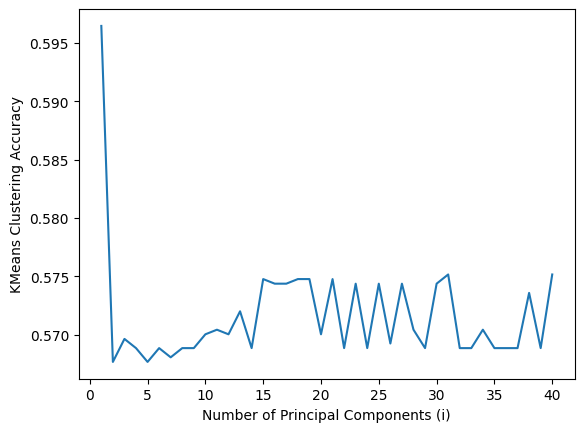

In [76]:
## Écrivez votre code ici.
accuracies=[]
for i in range(1,41):
    mypca=MyPCA(i)
    mypca.fit(X)
    X_pca_i = mypca.transform(X)
    km=MyKMeans(3)
    km.fit(X_pca_i)
    accuracies.append(accuracy(km.labels))

plt.plot(range(1,41),accuracies)
plt.xlabel("Number of Principal Components (i)")
plt.ylabel("KMeans Clustering Accuracy")

2. Faîtes la même chose mais avec 20 clusters.

Convergence atteinte à l'itération 73
Convergence atteinte à l'itération 41
Convergence atteinte à l'itération 38
Convergence atteinte à l'itération 17
Convergence atteinte à l'itération 38
Convergence atteinte à l'itération 17
Convergence atteinte à l'itération 47
Convergence atteinte à l'itération 31
Convergence atteinte à l'itération 22
Convergence atteinte à l'itération 36
Convergence atteinte à l'itération 36
Convergence atteinte à l'itération 39
Convergence atteinte à l'itération 34
Convergence atteinte à l'itération 28
Convergence atteinte à l'itération 40
Convergence atteinte à l'itération 35
Convergence atteinte à l'itération 42
Convergence atteinte à l'itération 51
Convergence atteinte à l'itération 33
Convergence atteinte à l'itération 21
Convergence atteinte à l'itération 35
Convergence atteinte à l'itération 45
Convergence atteinte à l'itération 31
Convergence atteinte à l'itération 22
Convergence atteinte à l'itération 65
Convergence atteinte à l'itération 38
Convergence 

Text(0, 0.5, 'KMeans Clustering Accuracy')

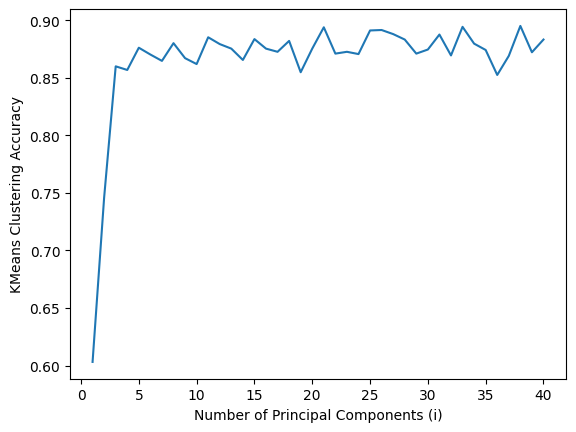

In [77]:
## Écrivez votre code ici.
accuracies=[]
for i in range(1,41):
    mypca=MyPCA(i)
    mypca.fit(X)
    X_pca_i = mypca.transform(X)
    km=MyKMeans(20)
    km.fit(X_pca_i)
    accuracies.append(accuracy(km.labels))

plt.plot(range(1,41),accuracies)
plt.xlabel("Number of Principal Components (i)")
plt.ylabel("KMeans Clustering Accuracy")

3. Calculez la précision des labels issus d'un K-clustering de `X` avec 100 clusters.

In [64]:
## Écrivez votre code ici.
mykm=MyKMeans(n_clusters=100)
mykm.fit(X)
labels= mykm.labels
acc=accuracy(labels)
print(acc)
    


Convergence atteinte à l'itération 18
0.9242603550295858


4. Calculez la précision des labels issus d'un K-clustering de la projection de `X` dans ses 50 premières composantes principales avec 100 clusters. Même chose avec 100 composantes principales. Qu'observez-vous ?

In [68]:
## Écrivez votre code ici.
mykm=MyKMeans(n_clusters=100)
mypc1=MyPCA(50)
mypc1.fit(X)
X_pca_50 = mypc1.transform(X)
mykm.fit(X_pca_50)
acc1=accuracy(mykm.labels)

mypc2=MyPCA(100)
mypc2.fit(X)
X_pca_100 = mypc2.transform(X)
mykm.fit(X_pca_100)
acc2=accuracy(mykm.labels)
print("accuracy with pca 50 components:", acc1)
print("accuracy with pca 100 components:", acc2)

Convergence atteinte à l'itération 29
Convergence atteinte à l'itération 18
accuracy with pca 50 components: 0.9226824457593689
accuracy with pca 100 components: 0.9191321499013807


## Exercice 7

Refaites les exercices 4, 5 et 6 avec `standardize=True`. Quelles différences observez-vous ? Comment pouvez-vous les expliquer ? Quelle version faut-il choisir ici ?

Avec la standardisation, toutes les variables ont la même variance, ce qui modifie les composantes principales et les distances utilisées par KMeans. Les clusters et la variance expliquée changent car PCA et KMeans sont sensibles à l’échelle des variables. Pour des données homogènes comme des pixels d’images, il est préférable de ne pas standardiser, car la variance porte une information utile.

## Exercice 8 

Quels intérêts et quels inconvénients y a t-il à faire son K-clustering sur des données projetées sur ses $n$ premiers composantes principales au lieu de le faire sur les données non-traitées ? Comment choisir $n$ ?

Intérêts :

Réduction du bruit : distances plus fiables

Moins de dimensions : KMeans plus rapide

Variables décorrélées :clustering plus stable

Inconvénients :

PCA peut supprimer des infos utiles à la séparation des groupes

Les nouvelles variables ne sont plus interprétables

Si la dimension initiale est faible, peu d’intérêt

Choix de 𝑛:
On prend le plus petit n expliquant ~90–95 % de la variance, ou on teste plusieurs valeurs et on garde celle donnant le meilleur clustering

